# Summary and Introduction
*(max 100 words)*

# Section 2: Creating a suitable `Env` Class

In [1]:
# Dependencies
import rclpy as ros
from rclpy.node import Node
from sensor_msgs.msg import LaserScan
import numpy as np
from numpy import Inf
from geometry_msgs.msg import Twist
from nav_msgs.msg  import Odometry
from std_srvs.srv import Empty
import random
from gazebo_msgs.srv import SpawnModel
import random
from math import atan2, pi
import matplotlib.pyplot as plt
import time

#import nbimporter # No longer required given provided RL.py files

ros.init()

In [2]:
# Creating Environment Class, which achieves the following:
#    1) Publishes robot movement messages
#    2) Subscribes to LaserScan /scan messages
#    3) Translates (2) into state-space (wall / goal / distance to goal)
#    4) Returns a reward number based on state

# ---- Things to do before submitting ----
#    1) Remove excess get_logger().info messages
#    2) 


class Env_TurtlebotAssessment2(Node):
    # Initialisation
    def __init__(self, name='ActionPublisher_StateSubscriber'
                 , frequency=0.01, n_spins = 64
                 , speed_linear=0.5, speed_angular=0.25
                 , n_beams = 24
                 , rewards = [10,-8, 0, -1], reward_scaler=1.0):
        super().__init__(name)
        self.get_logger().info('Environment Initialised')

        # Number of significant figures to round to for ease of debugging / reading
        self.n_sigfigs = 4

        # Number of times to spin (brute-force asynchronized messages)
        self.n_spins = n_spins
        # Counting the number of executions per test iteration
        self.n_action_executes = 0
        self.n_stop_executes = 0

        # Rewards for the robot
        self.reward_scaler = reward_scaler
        self.rewards = rewards
        self.cumulative_reward = 0

        # Initialising pose and movements
        # Basic default values for movement
        self.speed_linear = speed_linear    # Linear speed in m/s
        self.speed_angular = speed_angular  # Angular speed in rad/s
        self.action = 0                     # Default action set to "stop"
        self.robot = Twist()                # Twist object

        self.estimated_pose = np.zeros(3)   # x,y = (0,0), no yaw
        self.x = self.estimated_pose[0]
        self.y = self.estimated_pose[1]
        self.θ = self.estimated_pose[2]
        self.t = 0

        self.actions_list = {-1:'reverse'
                        , 0:'forward'
                        , 1:'turn left'
                        , 2:'turn right'}
        
        # Defining goals in environment
        self.goal_zone_radius = 0.6                                         # 2 feet == 0.6 metres
        self.goal_coordinates = np.array([[2,2], [-2,-2]])                  # Goal coordinates
        self.n_goals = self.goal_coordinates.shape[0]
        self.goal_distance = np.ones(self.n_goals)*Inf                    # Initial distance to goals
        self.euclid_distances_from_goals = np.ones(self.n_goals)*Inf       # Initial linear distances to goals
        self.angular_distances_from_goals = np.ones(self.n_goals)*Inf     # Initial angular distances to goals
        
        # Publishers
        self.controller = self.create_publisher(Twist, '/cmd_vel', 0)                       # Publishes /cmd_vel messages
        self.timer = self.create_timer(frequency, self.control)                             # Triggers self.controller to publish
        
        # Subscriptions
        self.odometer = self.create_subscription(Odometry, '/odom', self.odom_callback, 0)  # Receives Odometry
        self.scanner = self.create_subscription(LaserScan, '/scan', self.scan, 0)           # Receives LDS messages

        # LaserScans:
        # Default settings for scanner (in metres)
        self.range_max = 3.50   # Gazebo world is at least 4mx4m based on goal locations
        self.range_min = 0.25   # Any lower and turtlebot is at risk of flipping at higher velocities
        
        self.n_beams = n_beams                          # For future use in feature selection
        self.scans = np.ones(n_beams)*self.range_max

        # Defining compatibility measures
        # Number of Actions
        self.nA = len(self.actions_list)-1  # Removing the 'reverse' action
        
        # Number of states
        #   Suspect that this is a 4m x 4m world (given locations of goals)
        #   Footprint of turtlebot is ~0.14m x 0.18m
        #       Source: (https://emanual.robotis.com/docs/en/platform/turtlebot3/features/#:~:text=Small%20Size,test%20it%20anywhere%20you%20go.)
        #   Propose using [Area World] / [Area of Robot] / 2
        #       i.e. each state is ~two robots large
        #self.nS = int((4*4) / (0.14*0.18) // 2)

        # Defining state-space
        world_n_rows = world_n_cols = 20
        world_n_directions = n_beams                            # Default turn-speed is .5 rads/s
        self.nS = world_n_rows*world_n_cols*world_n_directions
        self.state_space = np.zeros((self.nS, self.n_beams))    # Creating a matrix to track states we have visited
        #self.s = 

        self.world_length = 4                                   # In Metres
        self.state_length = self.world_length/world_n_rows # This will be the tolerance of a scan to switch between on state and another

        # Compatibility
        self.Vstar = None

        # Creating a service client to reset the model pose
        self.reset_pose_client = self.create_client(Empty, "/reset_world")
        while not self.reset_pose_client.wait_for_service():
            self.get_logger().info("'reset_world' service not ready yet - waiting a bit longer ...")

    # Method to reset the model's pose (location + orientation)
    def reset_model_pose(self):
        self.reset_pose_client.call_async(Empty.Request())
        self.get_logger().info("Model Pose Reset")
    
    # Reset method with new name for compatibility purposes
    def reset(self):
        self.reset_model_pose()
        return self.s_()

    # Defining a method to flush messages
    def spin_n_times(self, n_spins=1):
        for _ in range(n_spins): ros.spin_once(self)

    # Movement related functions
    # Defining function to make robot take an action
    def step(self, action):
        #self.get_logger().info(f'Entered into "step" method with action: {action}')
        self.action = action

        speed_linear = speed_angular = 0.0                  # Changing default values
        match self.action:
            case -1: speed_linear = -self.speed_linear      # Reverse
            case  0: speed_linear = self.speed_linear       # Forward
            case  1: speed_angular = self.speed_angular     # Left
            case  2: speed_angular = -self.speed_angular    # Right
            case  _: speed_linear = speed_angular = 0.0     # Unrecognised action == stop
        
        self.robot.linear.x = speed_linear                  # Setting linear speed in Twist message
        self.robot.angular.z = speed_angular                # Setting angular speed in Twist message

        self.spin_n_times(self.n_spins)
        self.n_action_executes += 1
        self.get_logger().info(f'Instruction #{self.n_action_executes}: {self.actions_list[self.action]}')
        
        self.stop()
        self.spin_n_times(self.n_spins//2)

        # Calculate reward and special states after stopping
        reward, done, wall = self.reward(self.action)
        reward = round(reward, self.n_sigfigs)*self.reward_scaler
        self.cumulative_reward += reward
        self.get_logger().info(f'Reward: {reward}')

        # Returning in specific format for compatibility
        return self.s_(), reward, done, {}

    # Defining a stop function
    def stop(self):
        #self.get_logger().info('Entered into "stop" method')
        self.robot.linear.x = 0.0
        self.robot.angular.z = 0.0

    # Defining the action-message (i.e. Twist message) to be published
    def control(self):
        #self.get_logger().info(f'Entered into "control" method with action: {self.action}')
        self.controller.publish(self.robot)                 # Publish Twist message

    # Retrieve scan data
    def scan(self, scans):
        scans = np.array(scans.ranges)                      # Create numpy array that is same size as the scanner's results array
        scans[scans==Inf] = self.range_max                  # Cap the maximum range numbers received
        self.scans = scans
    
    # Retrieve Odometer pose-data
    # Use this information to calculate the distance to goal(s)
    def odom_callback(self, odom_reading):
        self.odom_reading = odom_reading

        # Converting from quarternion orientation to Euler representation
        # gives yaw = angle from 0 (straight forward) that the robot is positioned in
        orientation = self.odom_reading.pose.pose.orientation
        x,y,z,w = orientation.x, orientation.y, orientation.z, orientation.w
        yaw = atan2(2.0*(x*y + w*z), w*w + x*x - y*y - z*z)     # lifted from provided Lesson16 code

        # [linear_x_coord, linear_y_coord, yaw_angle]
        self.x = self.estimated_pose[0] = self.odom_reading.pose.pose.position.x
        self.y = self.estimated_pose[1] = self.odom_reading.pose.pose.position.y
        self.θ = self.estimated_pose[2] = yaw

        # Update distances with latest odom readings
        self.euclid_distances_from_goals = self.linear_distance_from_goal(self.goal_coordinates)
        self.angular_distances_from_goals = self.angular_distance_from_goal(self.goal_coordinates)

    # ----------------------------------------------------- #
    # ------ Determining special states of the robot ------ #
    # ----------------------------------------------------- #
    # Finding the Euclidean Distance from the robot to the goals (metres)
    def linear_distance_from_goal(self, goal_coordinates):
        goal_distances = np.zeros(self.n_goals)
        for i, goal in enumerate(goal_coordinates):
            goal_distances[i] = np.sqrt((goal[0] - self.estimated_pose[0])**2       # x
                                        + (goal[1] - self.estimated_pose[1])**2)    # y
        return goal_distances.round(self.n_sigfigs)
    
    # Finding the Angular Distances between the robot and the goals (radians)
    def angular_distance_from_goal(self, goal_coordinates):
        angular_distances = np.zeros(self.n_goals)

        # Robot orientation
        yaw = self.estimated_pose[2]
        if yaw < 0: yaw += 2*pi             # Positive numbers only

        # Finding the angle between the goal and the robot (radians)
        for i, goal in enumerate(goal_coordinates):
            angle_to_goal = atan2((abs(self.estimated_pose[0] - goal[0])),       # x
                                    (abs(self.estimated_pose[1] - goal[1])))     # y

            # Angle between robot and goal
            angular_distances[i] = abs(yaw - angle_to_goal)

        return angular_distances.round(self.n_sigfigs)

    # Checking to see if we are within the goal-zone
    def at_goal(self):
        at_goal = np.where(self.euclid_distances_from_goals <= self.goal_zone_radius)[0].shape[0] > 0
        if at_goal:
            print(f'!!!! Goal Reached !!!!')
            
        return at_goal
    
    # Checking to see if we are too close to the wall
    def hit_wall(self):
        # We are only looking in a ~90 degree forward cone
        n_forward_beams = int(self.scans.shape[0] // 4 // 2)
        forward_scans = np.concatenate((self.scans[-n_forward_beams:],
                                       self.scans[:n_forward_beams]))

        if forward_scans.min() < self.range_min: 
            self.get_logger().info(f'Hit the wall! Distance to wall: {forward_scans.min()}')
            self.reset_model_pose()
        
        return forward_scans.min() < self.range_min
    
    # Defining the reward to be returned to the robot after each step
    def reward(self, action):
        # Reward differently depending on whether it is at goal, hitting a wall, or
        #  going forward or taking some other action (we want to reward forward movement more)
        # Inspiration taken from provided Lesson16 notebook
        state_type = [self.at_goal(), self.hit_wall(), action==1, action!=1].index(True)
        
        reward = self.rewards[state_type]
        
        self.goal_distance = self.euclid_distances_from_goals + self.angular_distances_from_goals
        #self.get_logger().info(f'euclid_dist: {self.euclid_distances_from_goals}')
        #self.get_logger().info(f'angular_dist: {self.angular_distances_from_goals}')
        #self.get_logger().info(f'distances to goals: {self.goal_distance}')

        # Affect the "baseline" rewards by the negative of the distance to the closest goal
        # May need to add logic to avoid always choosing index 0 at equal distances
        if state_type: reward -= np.min(self.goal_distance)

        if state_type == 1: self.reset_model_pose()
        
        # Return the reward, whether it has reached the goal, and whether it has hit the wall
        return reward, state_type==0, state_type==1

    # ------------------------------------- #
    # ------ Returning current state ------ #
    # ------------------------------------- #
    def s_(self):
        '''
        # Find existing states that match our current scans (within tolerance)
        self.states_within_tol = np.where( 
                                    np.max(abs(self.state_space - self.scans),1)<=self.state_length)
        
        state_ind = self.states_within_tol[0]
        #self.get_logger().info(f'Existing states within tolerance: {state_ind}')
        
        if len(state_ind) == 0:        # If we cannot find the current scan in the state-space, make it a new entry
            # Find next empty state number
            state_ind = np.where(self.state_space==0)[0][0]
            self.state_space[state_ind] = self.scans
            self.get_logger().info(f'New state detected --> {state_ind}')
        else:
            state_ind = state_ind[0]
            self.get_logger().info(f'Currently in state: {state_ind}')
        
        '''

        state_ind = self.scans/self.scans.sum()

        return state_ind               # Normalizing the state-space
 
    # Compatibility
    def render(self, **kw):
        pass
    
    # ------------------------------- #
    # ------ Debugging methods ------ #
    # ------------------------------- #
    # Return scan data for diagnosis purposes
    def get_scans(self):
        ros.spin_once(self)
        return self.scans

    def get_pose(self):
        ros.spin_once(self)
        return self.odom_reading

    # Today:
        # A) Set goals in environment
            # Locations are at (2,2) and (-2, -2)
        # B) Use /odom to determine distance from goal(s)
            # [x] Euclidean distance +
            # [x] Arc-tan distance
        # C) Return reward
            # Determine special states
                # [x] At goal
                # [x] At wall (front only)
                # [x] Travelling
            # [x] Determine state space
            # [x] Assign rewards


## Testing basic environment

In [13]:
# Defining a test function to test basic functionality
# Moves robot to goal with explicit instructions
def test_robot(env):
    n_executes = []
    # Using a manual policy to test robot
    for _ in range(3): env.step(0)      # forward
    for _ in range(7): env.step(1)      # left
    for _ in range(7): env.step(0)      # forward

    n_executes.append((env.n_action_executes, env.n_stop_executes))
    env.n_action_executes = env.n_stop_executes = 0
    print(n_executes)
    return np.array(n_executes)

In [10]:
def test_robot_steps(env, steps_to_take):
    for _ in range(steps_to_take): env.step(0)

In [11]:
test_env = Env_TurtlebotAssessment2(frequency=0.01, n_spins=64)

[INFO] [1714238064.423533922] [ActionPublisher_StateSubscriber]: Environment Initialised


In [15]:
#test = test_robot(test_env)
#test = test_robot_steps(test_env, 1)

# Section 3: Model 1
## Action Value-Function with Linear Function Approximation

In [3]:
from RLv import *

In [4]:
class Env_LFA(Env_TurtlebotAssessment2):
    def __init__(self, nF=24, **kw):
        self.nF = nF
        super().__init__(**kw)
    '''
    def s_(self):
        # Down-sample to the number of features desired
        # (if there's time - use weighted average or average pooling)
        feature_ind = np.round(np.linspace(0,self.n_beams-1, self.nF), 0).astype(int)
        φ = self.scans[feature_ind]
        φ[φ==Inf] = self.range_max
        return φ/φ.sum()    # Normalizing features
    '''
    
    # Defining a one-hot encoded feature vector
    def S_(self):
        return np.eye(self.nF)

In [9]:
env_vectorised = Env_LFA(frequency = 1/20, n_spins=28, nF=24
                       , speed_linear = .7, speed_angular = 0.5*pi
                       , reward_scaler = 1.0)

[WARN] [1714238242.682317121] [rcl.logging_rosout]: Publisher already registered for provided node name. If this is due to multiple nodes with the same name then all logs for that logger name will go out over the existing publisher. As soon as any node with that name is destructed it will unregister the publisher, preventing any further logs for that name from being published on the rosout topic.
[INFO] [1714238242.689749990] [ActionPublisher_StateSubscriber]: Environment Initialised


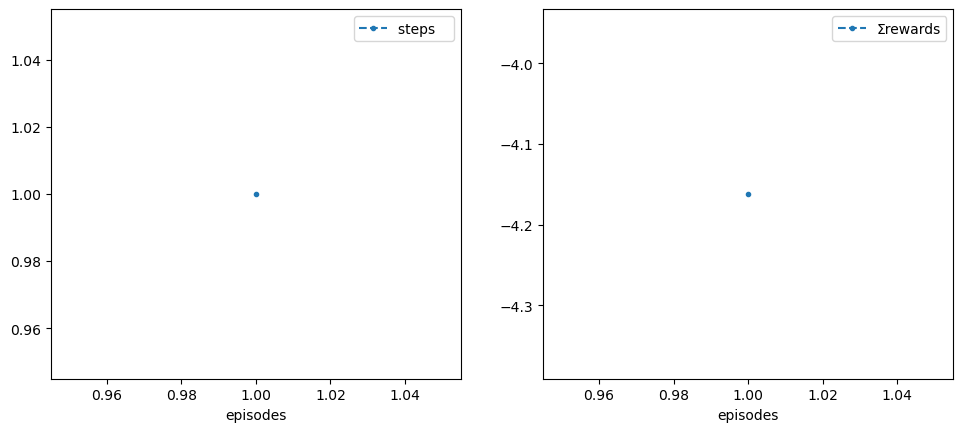

In [12]:
vectorised_sarsa = trueSarsaλ(env=env_vectorised, max_t=2, episodes=1, seed=1, λ=.7, α=.4, **demoGame()).interact()

In [16]:
vectorised_sarsa.env.nS

9600

In [13]:
vectorised_sarsa.s

array([[9610, 9610, 9610, 9610, 9610, 9610, 9610, 9610, 9610, 9610, 9610,
        9610, 9610, 9610, 9610, 9610, 9610, 9610, 9610, 9610, 9610, 9610,
        9610, 9610],
       [9610, 9610, 9610, 9610, 9610, 9610, 9610, 9610, 9610, 9610, 9610,
        9610, 9610, 9610, 9610, 9610, 9610, 9610, 9610, 9610, 9610, 9610,
        9610, 9610]], dtype=uint32)

In [5]:
def multi_runs(max_t=1000, episodes=50, seed=1, lambda_alphas = [(.6,.1)]):
    episode_steps = []
    episode_rewards = []
    
    for hyper_params in lambda_alphas:
        λ = hyper_params[0]
        α = hyper_params[1]
        print(f'Running with λ:{λ} and α: {α}')
        
        # Reset environment
        env_vectorised = Env_LFA(frequency = 1/20, n_spins=28, nF=24
                        , speed_linear = .7, speed_angular = 0.5*pi
                        , reward_scaler = 1.0)
        
        # Reset trueSarsa-lambda MDP
        vectorised_sarsa = trueSarsaλ(env=env_vectorised
                                      , max_t=max_t, episodes=episodes
                                      , seed=seed, λ=λ, α=α).interact()
        episode_steps.append(vectorised_sarsa.Ts)
        episode_rewards.append(vectorised_sarsa.Rs)
        vectorised_sarsa.env.reset()

    return episode_steps, episode_rewards        

In [8]:
# Format: (λ, α)
'''
lambda_alphas = [(.7, .5), (.7, .4), (.7,.2)
                 , (.8, .5), (.8, .4), (.8, .2)
                 , (.9, .5), (.9, .4), (.9, .2)]
'''

lambda_alphas = [(.7,.4), (.8, .3), (.9, .2)]

steps, rewards = multi_runs(max_t=2, episodes=1)#, lambda_alphas=lambda_alphas)

Running with λ:0.6 and α: 0.1


[WARN] [1714238222.364913364] [rcl.logging_rosout]: Publisher already registered for provided node name. If this is due to multiple nodes with the same name then all logs for that logger name will go out over the existing publisher. As soon as any node with that name is destructed it will unregister the publisher, preventing any further logs for that name from being published on the rosout topic.
[INFO] [1714238222.371988219] [ActionPublisher_StateSubscriber]: Environment Initialised
[INFO] [1714238222.378822529] [ActionPublisher_StateSubscriber]: Model Pose Reset
[INFO] [1714238223.275953377] [ActionPublisher_StateSubscriber]: Instruction #1: forward
[INFO] [1714238223.725899474] [ActionPublisher_StateSubscriber]: Reward: -4.162
[INFO] [1714238223.729093965] [ActionPublisher_StateSubscriber]: Model Pose Reset


<function matplotlib.pyplot.show(close=None, block=None)>

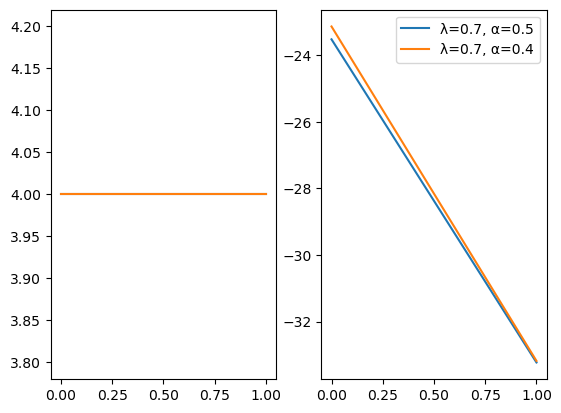

In [ ]:
for i in range(len(steps)):
    plt.subplot(1,2,1).plot(steps[i])
    plt.subplot(1,2,2).plot(rewards[i]
                            , label=f'λ={lambda_alphas[i][0]}, α={lambda_alphas[i][1]}')

plt.legend()
plt.show

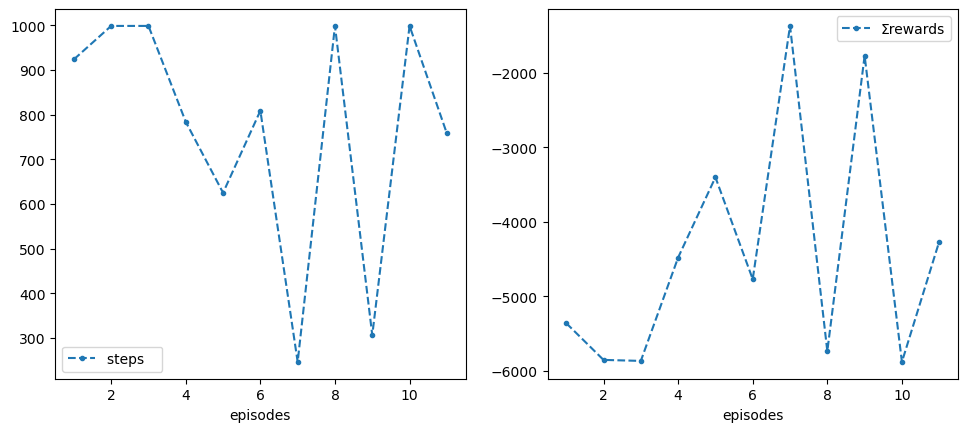

[INFO] [1714237527.730396106] [ActionPublisher_StateSubscriber]: Model Pose Reset
[INFO] [1714237528.541669415] [ActionPublisher_StateSubscriber]: Instruction #8449: forward
[INFO] [1714237529.001988211] [ActionPublisher_StateSubscriber]: Reward: -9.0962
[INFO] [1714237529.941688678] [ActionPublisher_StateSubscriber]: Instruction #8450: turn left
[INFO] [1714237530.402987313] [ActionPublisher_StateSubscriber]: Reward: -3.097
[INFO] [1714237531.341677715] [ActionPublisher_StateSubscriber]: Instruction #8451: forward
[INFO] [1714237531.803773262] [ActionPublisher_StateSubscriber]: Reward: -3.4844
[INFO] [1714237532.741694574] [ActionPublisher_StateSubscriber]: Instruction #8452: forward
[INFO] [1714237533.205080113] [ActionPublisher_StateSubscriber]: Hit the wall! Distance to wall: 0.1729947179555893
[INFO] [1714237533.208076778] [ActionPublisher_StateSubscriber]: Model Pose Reset
[INFO] [1714237533.210861189] [ActionPublisher_StateSubscriber]: Model Pose Reset
[INFO] [1714237533.2132802

KeyboardInterrupt: 

In [8]:
test_env_lfa = Env_LFA(frequency = 1/20, n_spins=28, nF=24
                        , speed_linear = .7, speed_angular = 0.5*pi
                        , reward_scaler = 1.0)

vsarsa = trueSarsaλ(env=test_env_lfa, max_t=1000, episodes=50, seed=1, λ=0.7, α=0.4, **demoGame()).interact()

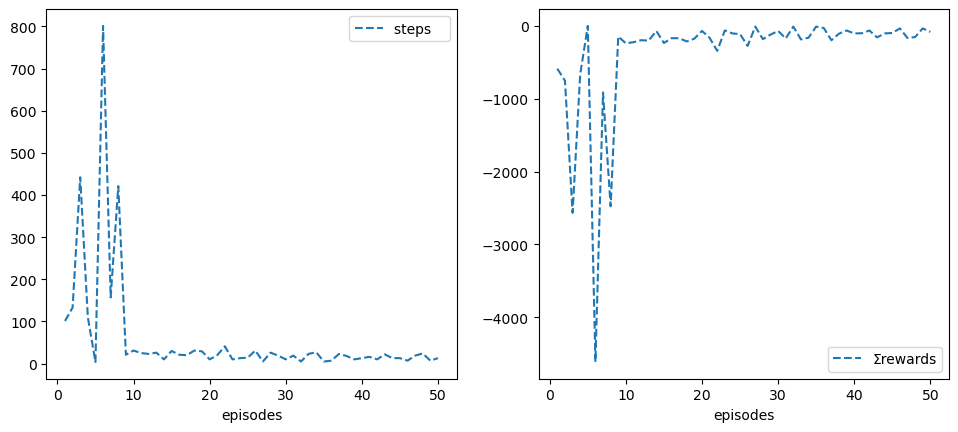

In [46]:
# settings worked!
#vsarsa = trueSarsaλ(env=test_env_lfa, max_t=1000, episodes=50, seed=1, λ=0.7, α=0.4, **demoGame()).interact()

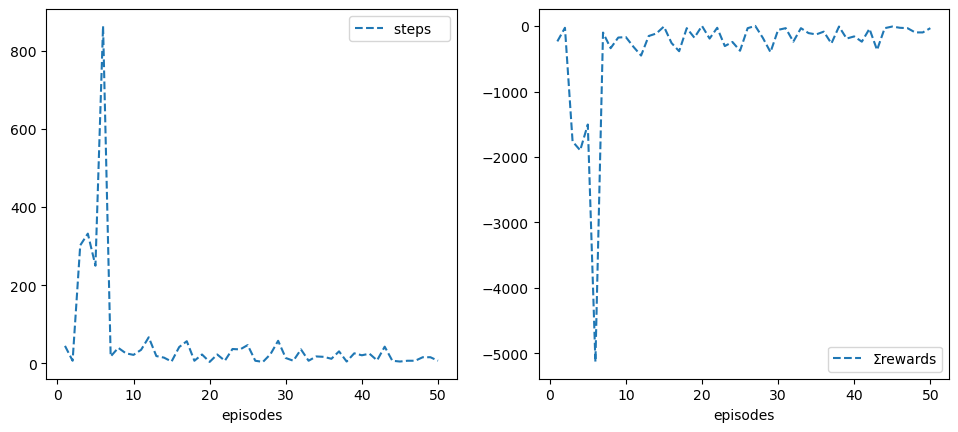

In [51]:
'''
# A sarsa algorithm that weights future rewards more (offset with a slower learning rate)
env_vsarsa_2 = Env_LFA(frequency = 1/20, n_spins=28, nF=24
                       , speed_linear = .8, speed_angular = 0.5*pi
                       , reward_scaler = 1.0)
vsarsa_2 = trueSarsaλ(env=env_vsarsa_2, max_t=1000, episodes=50, seed=1, λ=0.9, α=0.2, **demoGame()).interact()
'''

# Section 4: Model 2
## Policy Gradient with Non-Linear Function Approximation

### Setup: Importing required modules and device testing

In [2]:
# Importing dependencies
from collections import deque
from itertools import islice
import tensorflow as tf

# Importing required classes and functions from `RLnn.py`
# Note that this overrides some of the classes and functions imported from `RL.py` and `RLv.py`
# Full notebook reset will be required once this is run
from RLnn import MRP, MDP

In [15]:
# Listing version of software used
print(f"tensorflow version: {tf.__version__}")
print("cudnn_version",tf.sysconfig.get_build_info()['cudnn_version'])
print("cuda_version",tf.sysconfig.get_build_info()['cuda_version'])

# Checking for device availability
print(f"Number of GPU devices available: {len(tf.config.list_physical_devices('GPU'))}")

tensorflow version: 2.16.1
cudnn_version 8
cuda_version 12.3
Number of GPU devices available: 1
